# Libraries

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from lightgbm import LGBMClassifier

# Importing Data

In [2]:
df = pd.read_csv("OnlineNewsPopularity.csv", sep= ',')
df

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.70,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.70,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.00,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.80,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.00,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,http://mashable.com/2014/12/27/samsung-app-aut...,8.0,11.0,346.0,0.529052,1.0,0.684783,9.0,7.0,1.0,...,0.100000,0.75,-0.260000,-0.500,-0.125000,0.100000,0.000000,0.400000,0.000000,1800
39640,http://mashable.com/2014/12/27/seth-rogen-jame...,8.0,12.0,328.0,0.696296,1.0,0.885057,9.0,7.0,3.0,...,0.136364,0.70,-0.211111,-0.400,-0.100000,0.300000,1.000000,0.200000,1.000000,1900
39641,http://mashable.com/2014/12/27/son-pays-off-mo...,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,...,0.136364,0.50,-0.356439,-0.800,-0.166667,0.454545,0.136364,0.045455,0.136364,1900
39642,http://mashable.com/2014/12/27/ukraine-blasts/,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,...,0.062500,0.50,-0.205246,-0.500,-0.012500,0.000000,0.000000,0.500000,0.000000,1100


# IDA

## Checking Missing Values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

In [4]:
df.isnull().sum()

url                              0
 timedelta                       0
 n_tokens_title                  0
 n_tokens_content                0
 n_unique_tokens                 0
                                ..
 title_subjectivity              0
 title_sentiment_polarity        0
 abs_title_subjectivity          0
 abs_title_sentiment_polarity    0
 shares                          0
Length: 61, dtype: int64

# EDA

In [5]:
df[' shares'].describe()

count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name:  shares, dtype: float64

In [6]:
df[' shares'].skew()

np.float64(33.96388487571415)

## Hapus Variabel gk Penting 

In [7]:
df.columns = df.columns.str.strip()
df = df.drop(columns=['url']) #karena URL gk kepake baik dalam visualisasi maupun modeling

## Decoding

 Decoding Code nya kembali agar bisa di visualisasi dan dibaca

### Decode Channel

In [8]:
# —Decode Channel 
channel_map = {
    'data_channel_is_lifestyle':     'Lifestyle',
    'data_channel_is_entertainment': 'Entertainment',
    'data_channel_is_bus':           'Business',
    'data_channel_is_socmed':        'Social Media',
    'data_channel_is_tech':          'Tech',
    'data_channel_is_world':         'World',
}
def decode_channel(row):
    for col, label in channel_map.items():
        if row[col] == 1:
            return label
    return 'Other'

df['channel'] = df.apply(decode_channel, axis=1)
df = df.drop(columns=list(channel_map.keys()))

df

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,channel
0,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,...,0.70,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593,Entertainment
1,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,...,0.70,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711,Business
2,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,...,1.00,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500,Business
3,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,...,0.80,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200,Entertainment
4,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,...,1.00,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505,Tech
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,8.0,11.0,346.0,0.529052,1.0,0.684783,9.0,7.0,1.0,1.0,...,0.75,-0.260000,-0.500,-0.125000,0.100000,0.000000,0.400000,0.000000,1800,Tech
39640,8.0,12.0,328.0,0.696296,1.0,0.885057,9.0,7.0,3.0,48.0,...,0.70,-0.211111,-0.400,-0.100000,0.300000,1.000000,0.200000,1.000000,1900,Social Media
39641,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,1.0,...,0.50,-0.356439,-0.800,-0.166667,0.454545,0.136364,0.045455,0.136364,1900,Other
39642,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,0.0,...,0.50,-0.205246,-0.500,-0.012500,0.000000,0.000000,0.500000,0.000000,1100,World


### Decode Weekday

In [9]:
# Decode Weekday 
weekday_map = {
    'weekday_is_monday':    'Monday',
    'weekday_is_tuesday':   'Tuesday',
    'weekday_is_wednesday': 'Wednesday',
    'weekday_is_thursday':  'Thursday',
    'weekday_is_friday':    'Friday',
    'weekday_is_saturday':  'Saturday',
    'weekday_is_sunday':    'Sunday',
}
def decode_weekday(row):
    for col, label in weekday_map.items():
        if row[col] == 1:
            return label
    return 'Unknown'

df['weekday'] = df.apply(decode_weekday, axis=1)
df = df.drop(columns=list(weekday_map.keys()))
df = df.drop(columns=['is_weekend'])  # redundant

### Decode LDA

In [10]:
# Decode LDA → Dominant Topic 
lda_cols = ['LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04']
df['dominant_topic'] = df[lda_cols].idxmax(axis=1).str.replace('LDA_0', 'Topic ')

In [11]:
df

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,channel,weekday,dominant_topic
0,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,...,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593,Entertainment,Monday,Topic 0
1,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,...,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711,Business,Monday,Topic 0
2,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,...,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500,Business,Monday,Topic 4
3,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,...,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200,Entertainment,Monday,Topic 2
4,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,...,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505,Tech,Monday,Topic 4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,8.0,11.0,346.0,0.529052,1.0,0.684783,9.0,7.0,1.0,1.0,...,-0.500,-0.125000,0.100000,0.000000,0.400000,0.000000,1800,Tech,Wednesday,Topic 4
39640,8.0,12.0,328.0,0.696296,1.0,0.885057,9.0,7.0,3.0,48.0,...,-0.400,-0.100000,0.300000,1.000000,0.200000,1.000000,1900,Social Media,Wednesday,Topic 3
39641,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,1.0,...,-0.800,-0.166667,0.454545,0.136364,0.045455,0.136364,1900,Other,Wednesday,Topic 3
39642,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,0.0,...,-0.500,-0.012500,0.000000,0.000000,0.500000,0.000000,1100,World,Wednesday,Topic 2


Fungsi Decoding ini biar nantinya kita bisa membuat dan melihat visualisasinya 

## Klasifikasi jadi 2 Bagian (No Popular/ Popular)

jadi kami disini membagi jadi 2 bagian Not Popular / Popular dan kami memisahkannya menggunakan median

nilai shares memiliki variasi yang sangat besar dan dipengaruhi oleh perilaku pengguna internet yang sulit diprediksi secara tepat sehingga itu lah kami bagi jadi 2

Selain itu juga kenapa gk clustering seperti K-means malahan dibagai jadi quantile karena data ini right skewed dan terdapat nilai extreme sehingga membaginya jadi quantile lebih tahan terhadap outlier dan niali extreme

In [ ]:
median_shares = df['shares'].median()
print(f"Median Shares (threshold) : {median_shares:.0f}")

df['popularity'] = (df['shares'] >= median_shares).astype(int)
# 0 = Not Popular, 1 = Popular
df = df.drop(columns=['shares'])

counts = df['popularity'].value_counts().sort_index()
labels_map = {0: 'Not Popular', 1: 'Popular'}
print(f"Distribusi Kelas:")
for k, v in counts.items():
    print(f"{labels_map[k]:12}: {v:5d} samples ({v/len(df)*100:.1f}%)")

📊 Median Shares (threshold) : 1400

📊 Distribusi Kelas:
   Not Popular : 18490 samples (46.6%)
   Popular     : 21154 samples (53.4%)


## Visualisasi

### Style 

In [13]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

### Distribusi Kategori Popularity

C:\Users\Xov\AppData\Local\Temp\ipykernel_17864\2725157403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


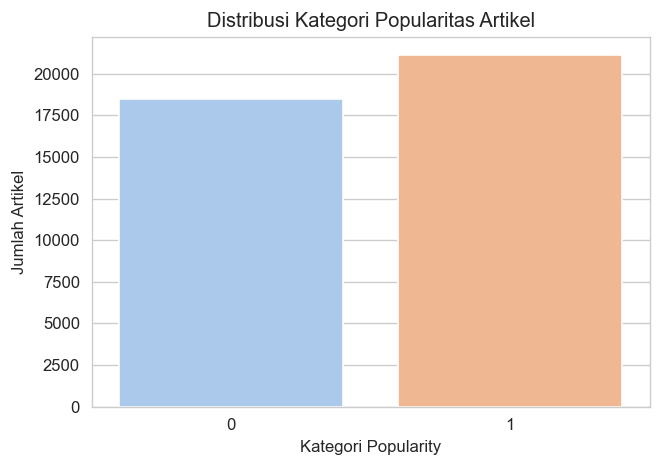

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='popularity',
    palette='pastel'
)

plt.title('Distribusi Kategori Popularitas Artikel')
plt.xlabel('Kategori Popularity')
plt.ylabel('Jumlah Artikel')

plt.show()

Hal ini menunjukkan bahwa metode pembagian menggunakan quantile berhasil menghasilkan distribusi kelas yang balance. Kondisi ini bagus untuk machine learning karena model tidak terlalu bias terhadap salah satu kelas.

### Jumlah Artikel per Channel berdasarkan Popularity

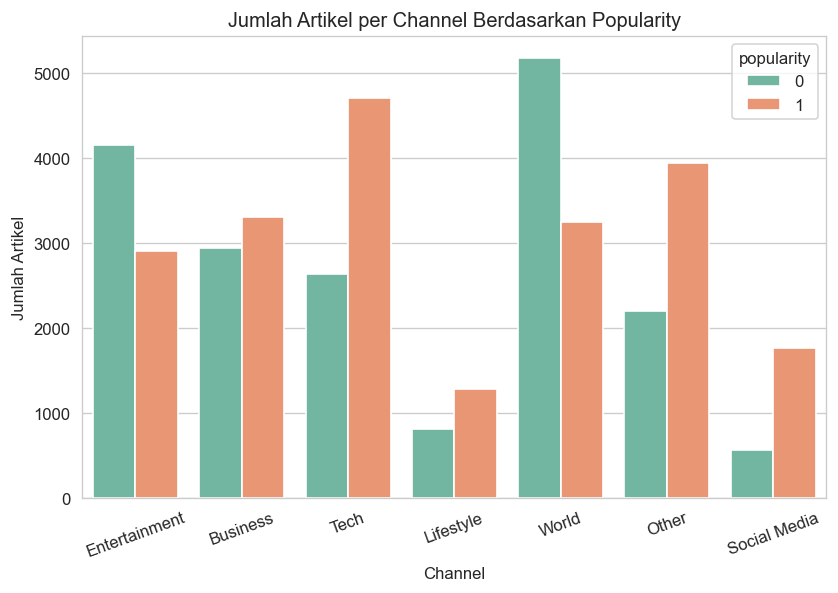

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='channel',
    hue='popularity',
    palette='Set2'
)

plt.title('Jumlah Artikel per Channel Berdasarkan Popularity')
plt.xlabel('Channel')
plt.ylabel('Jumlah Artikel')

plt.xticks(rotation=20)
plt.show()

Threshold popularitas = median shares (1.400). Hampir semua channel didominasi artikel populer, kecuali World dan Entertainment. Tech memiliki artikel populer terbanyak, Social Media dan Lifestyle paling sedikit.

### Jumlah Gambar vs Popularity

C:\Users\Xov\AppData\Local\Temp\ipykernel_17864\2725579047.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


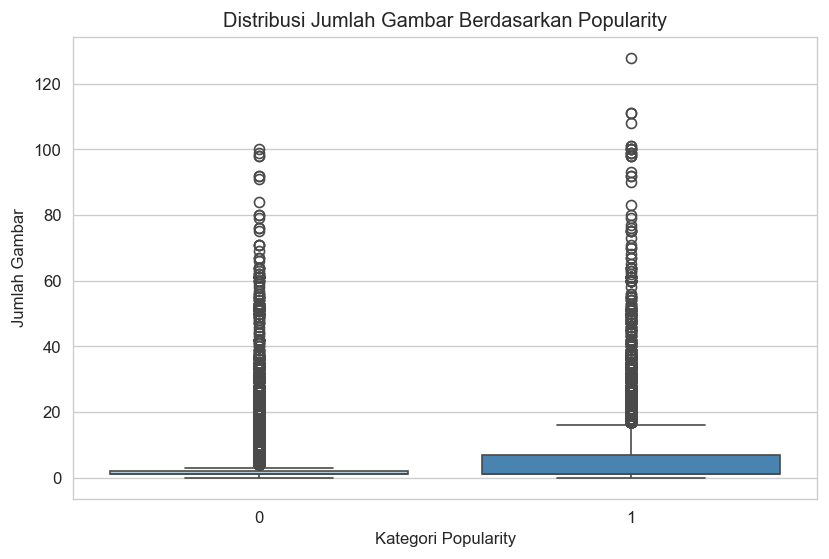

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='popularity',
    y='num_imgs',
    palette='Blues'
)

plt.title('Distribusi Jumlah Gambar Berdasarkan Popularity')
plt.xlabel('Kategori Popularity')
plt.ylabel('Jumlah Gambar')

plt.show()

Artikel populer memiliki median gambar lebih tinggi dan outlier lebih ekstrem. Ada indikasi bahwa semakin banyak gambar, semakin besar peluang artikel untuk populer.

### Jumlah Video vs Popularity

C:\Users\Xov\AppData\Local\Temp\ipykernel_17864\1795916404.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


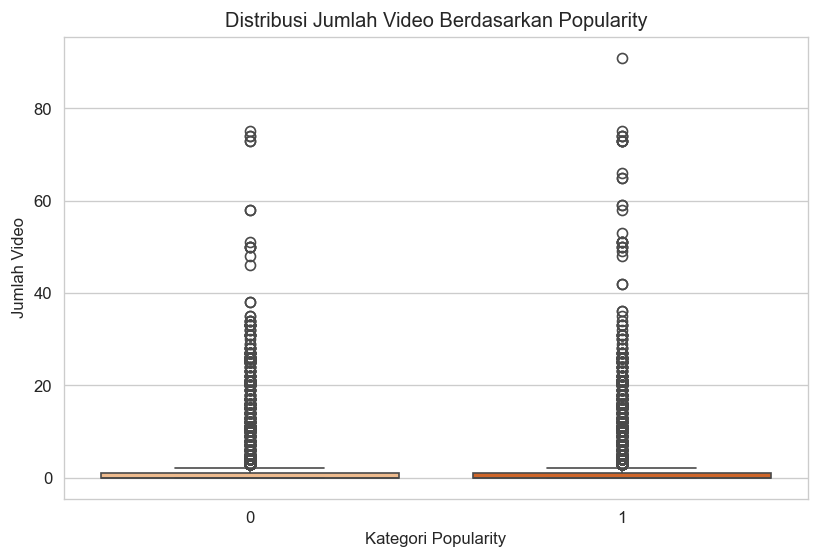

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='popularity',
    y='num_videos',
    palette='Oranges'
)

plt.title('Distribusi Jumlah Video Berdasarkan Popularity')
plt.xlabel('Kategori Popularity')
plt.ylabel('Jumlah Video')

plt.show()

Median keduanya mendekati 0, artinya sebagian besar artikel tidak punya video. Perbedaan antar kelompok sangat kecil, sehingga jumlah video bukan pembeda yang signifikan.

### Panjang Artikel vs Popularity

C:\Users\Xov\AppData\Local\Temp\ipykernel_17864\1169726700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


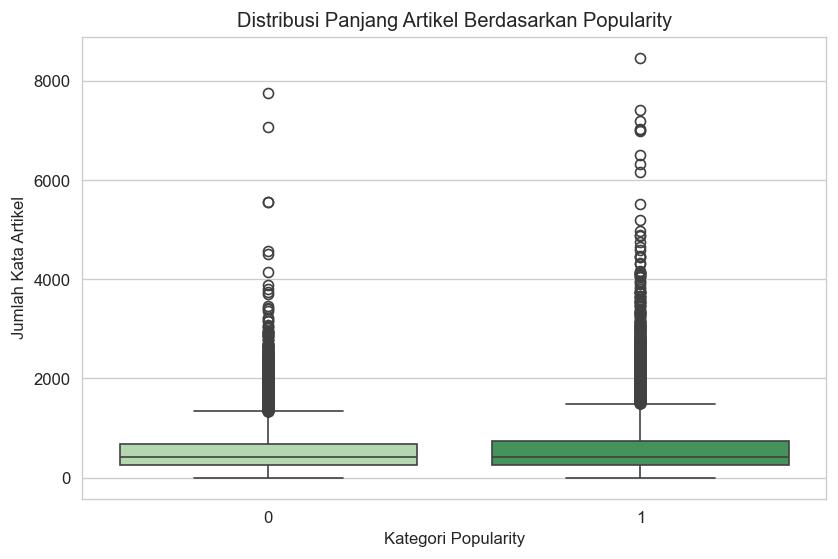

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='popularity',
    y='n_tokens_content',
    palette='Greens'
)

plt.title('Distribusi Panjang Artikel Berdasarkan Popularity')
plt.xlabel('Kategori Popularity')
plt.ylabel('Jumlah Kata Artikel')

plt.show()

Distribusi keduanya hampir identik dengan median sekitar 400-600 kata. Panjang artikel tidak menjadi faktor pembeda yang kuat terhadap popularitas.

### Sentiment Polarity vs Popularity

C:\Users\Xov\AppData\Local\Temp\ipykernel_17864\211301130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


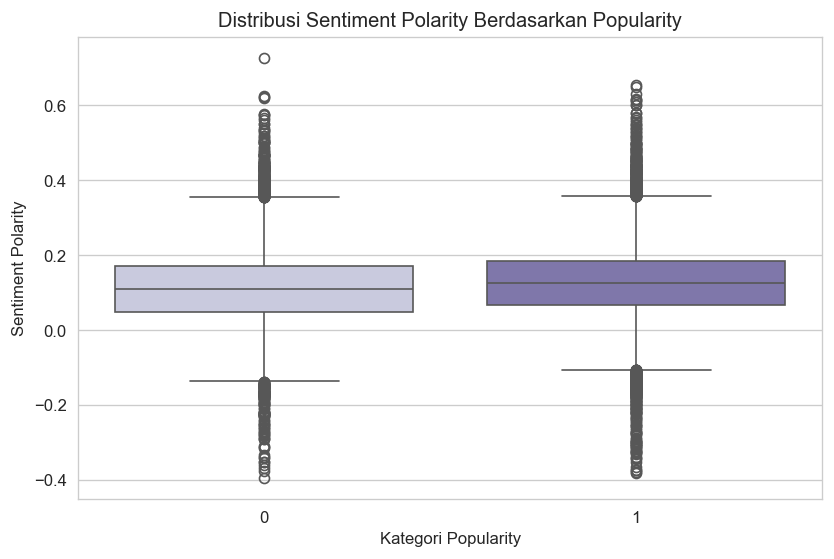

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='popularity',
    y='global_sentiment_polarity',
    palette='Purples'
)

plt.title('Distribusi Sentiment Polarity Berdasarkan Popularity')
plt.xlabel('Kategori Popularity')
plt.ylabel('Sentiment Polarity')

plt.show()

Kedua kelompok punya median sekitar 0.10-0.13 (sedikit positif) dengan distribusi yang hampir sama. Sentimen artikel tidak berpengaruh besar terhadap popularitas.

### Dominant Topic berdasarkan Popularity

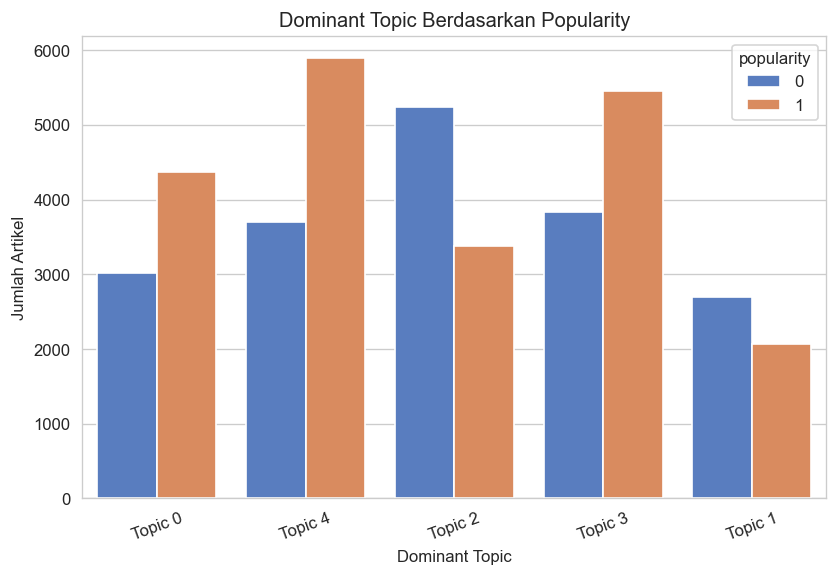

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='dominant_topic',
    hue='popularity',
    palette='muted'
)

plt.title('Dominant Topic Berdasarkan Popularity')
plt.xlabel('Dominant Topic')
plt.ylabel('Jumlah Artikel')

plt.xticks(rotation=20)
plt.show()

Topic 4 paling banyak menghasilkan artikel populer, sementara Topic 2 justru didominasi artikel tidak populer. Topik LDA cukup relevan sebagai pembeda popularitas.

## Splitting Data

In [21]:
X = df.drop(columns=['popularity'])
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify penting untuk klasifikasi
)
print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")


Train size : (31715, 48)
Test size  : (7929, 48)


## Encoding 

In [22]:
cat_cols = ['channel', 'weekday', 'dominant_topic']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col]  = X_test[col].map(
        lambda val, le=le: le.transform([val])[0] if val in le.classes_ else -1
    )
    encoders[col] = le

print(f"Kolom train : {X_train.select_dtypes('object').columns.tolist()}")
print(f"Kolom test  : {X_test.select_dtypes('object').columns.tolist()}")

Kolom train : []
Kolom test  : []


# Modeling

In [23]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

## Evaluation Function

In [26]:
def evaluate_clf(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Not Popular', 'Popular'])}")
    return {'name': name, 'acc': acc, 'y_pred': y_pred}

results = {}

## Baseline Model

### Random Forest

In [27]:
print("Training Baseline Random Forest")
rf_base = RandomForestClassifier(
    n_estimators=200, max_depth=15,
    min_samples_leaf=5, n_jobs=-1, random_state=42
)
rf_base.fit(X_train, y_train)
results['RF_base'] = evaluate_clf('Random Forest (Baseline)', y_test, rf_base.predict(X_test))

Training Baseline Random Forest

─────────────────────────────────────────────
  Random Forest (Baseline)
─────────────────────────────────────────────
  Accuracy : 0.6559 (65.59%)

              precision    recall  f1-score   support

 Not Popular       0.65      0.57      0.61      3698
     Popular       0.66      0.73      0.69      4231

    accuracy                           0.66      7929
   macro avg       0.65      0.65      0.65      7929
weighted avg       0.66      0.66      0.65      7929



### Light GBM

In [35]:
print("Training Baseline Light GBM")
lgbm_base = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    random_state=42
)

lgbm_base.fit(X_train, y_train)
results['lgbm_base'] = evaluate_clf('Light GBM (Baseline)', y_test, lgbm_base.predict(X_test))

Training Baseline Light GBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001880 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8685
[LightGBM] [Info] Number of data points in the train set: 31715, number of used features: 48
[LightGBM] [Info] Start training from score -0.762703
[LightGBM] [Info] Start training from score -0.628116
[LightGBM] [Info] Start training from score -34.538776

─────────────────────────────────────────────
  Light GBM (Baseline)
─────────────────────────────────────────────
  Accuracy : 0.6653 (66.53%)

              precision    recall  f1-score   support

 Not Popular       0.65      0.61      0.63      3698
     Popular       0.68      0.72      0.70      4231

    accuracy                           0.67      7929
   macro avg       0.66      0.66      0.66      7929
weighted avg       0.66      0.67     

### XG Boost

In [29]:
print("Training Baseline XGBoost")
xgb_base = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss',          # binary → logloss bukan mlogloss
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_base.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
results['XGB_base'] = evaluate_clf('XGBoost (Baseline)', y_test, xgb_base.predict(X_test))


Training Baseline XGBoost

─────────────────────────────────────────────
  XGBoost (Baseline)
─────────────────────────────────────────────
  Accuracy : 0.6716 (67.16%)

              precision    recall  f1-score   support

 Not Popular       0.66      0.62      0.64      3698
     Popular       0.68      0.72      0.70      4231

    accuracy                           0.67      7929
   macro avg       0.67      0.67      0.67      7929
weighted avg       0.67      0.67      0.67      7929



## Hyperparameter Tuning model 

### Random Forest

In [30]:
print("Tuning Random Forest")
rf_params = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [10, 15, 20, 25, None],
    'min_samples_leaf': [2, 5, 10, 20],
    'max_features':     ['sqrt', 'log2', 0.5, 0.7],
    'bootstrap':        [True, False]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42),
    rf_params, n_iter=30, cv=3,
    scoring='accuracy', random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
results['RF_tuned'] = evaluate_clf('Random Forest (Tuned)', y_test,
                                    rf_search.best_estimator_.predict(X_test))

Tuning Random Forest
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best RF params: {'n_estimators': 500, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 25, 'bootstrap': False}

─────────────────────────────────────────────
  Random Forest (Tuned)
─────────────────────────────────────────────
  Accuracy : 0.6568 (65.68%)

              precision    recall  f1-score   support

 Not Popular       0.65      0.57      0.61      3698
     Popular       0.66      0.73      0.69      4231

    accuracy                           0.66      7929
   macro avg       0.66      0.65      0.65      7929
weighted avg       0.66      0.66      0.65      7929



### XG Boost

In [31]:
print("Tuning XGBoost")
xgb_params = {
    'n_estimators':     [200, 300, 500, 700],
    'max_depth':        [4, 6, 8, 10],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'subsample':        [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 10],
    'gamma':            [0, 0.1, 0.3, 0.5]
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                  random_state=42, n_jobs=-1, verbosity=0),
    xgb_params, n_iter=30, cv=3,
    scoring='accuracy', random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
print(f"Best XGB params: {xgb_search.best_params_}")
results['XGB_tuned'] = evaluate_clf('XGBoost (Tuned)', y_test,
                                     xgb_search.best_estimator_.predict(X_test))

Tuning XGBoost
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best XGB params: {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.7}

─────────────────────────────────────────────
  XGBoost (Tuned)
─────────────────────────────────────────────
  Accuracy : 0.6723 (67.23%)

              precision    recall  f1-score   support

 Not Popular       0.66      0.61      0.64      3698
     Popular       0.68      0.72      0.70      4231

    accuracy                           0.67      7929
   macro avg       0.67      0.67      0.67      7929
weighted avg       0.67      0.67      0.67      7929



### Light GBM

In [36]:
print("Tuning LightGBM")
lgbm_params = {
    'n_estimators': [100, 300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 5, 8, 12],
    'num_leaves': [15, 31, 50, 70],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [10, 20, 30]
}
lgbm_search = RandomizedSearchCV(
    LGBMClassifier( objective='multiclass',
    num_class=3,
    random_state=42),
    lgbm_params, n_iter=30, cv=3,
    scoring='accuracy', random_state=42, n_jobs=-1, verbose=1
)
lgbm_search.fit(X_train, y_train)
print(f"Best lgbm params: {lgbm_search.best_params_}")
results['LGBM_tuned'] = evaluate_clf('Light GBM (Tuned)', y_test,
                                     lgbm_search.best_estimator_.predict(X_test))

Tuning LightGBM
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8685
[LightGBM] [Info] Number of data points in the train set: 31715, number of used features: 48
[LightGBM] [Info] Start training from score -0.762703
[LightGBM] [Info] Start training from score -0.628116
[LightGBM] [Info] Start training from score -34.538776
Best lgbm params: {'subsample': 0.8, 'num_leaves': 70, 'n_estimators': 700, 'min_child_samples': 30, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

─────────────────────────────────────────────
  Light GBM (Tuned)
─────────────────────────────────────────────
  Accuracy : 0.6727 (67.27%)

              precision    recall  f1-score   support

 Not Popular       0.66      0.61      0.64      3698
     Popular       0.68      0.72      0.70      4231

## Visualisasi Model

### top 20 Feature Importance

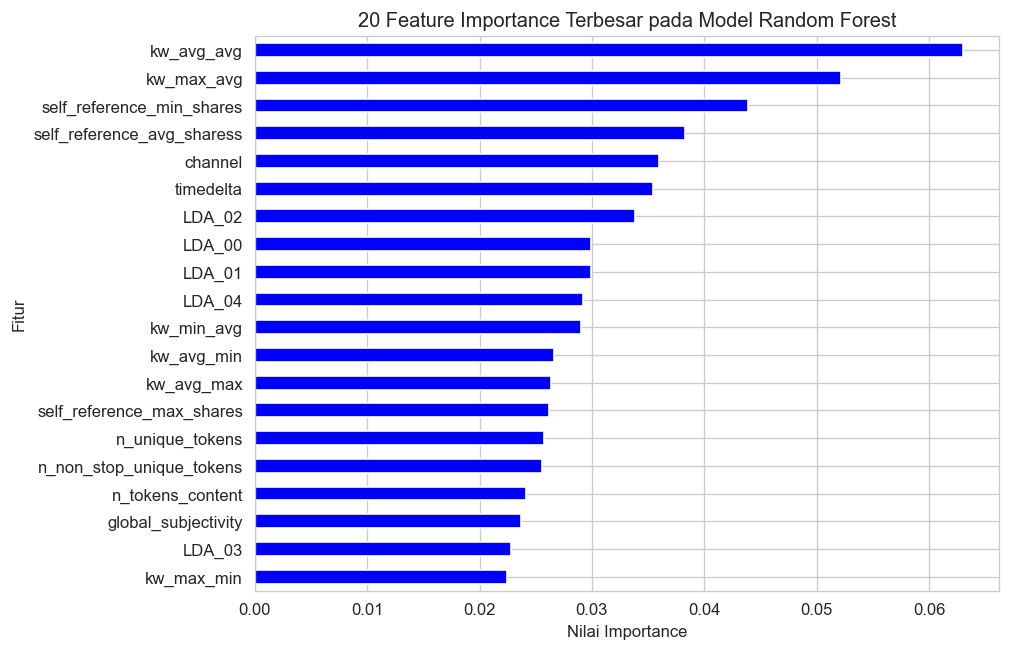

In [40]:
# Mengambil feature importance dari model Random Forest
feature_importance = pd.Series(
    rf_search.best_estimator_.feature_importances_,
    index=X_train.columns
)

# Ambil 20 fitur terpenting
top_features = feature_importance.nlargest(20).sort_values()

# Membuat plot
plt.figure(figsize=(8,6))

top_features.plot(
    kind='barh',
    color='Blue'
)

plt.title('20 Feature Importance Terbesar pada Model Random Forest')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur')

plt.show()

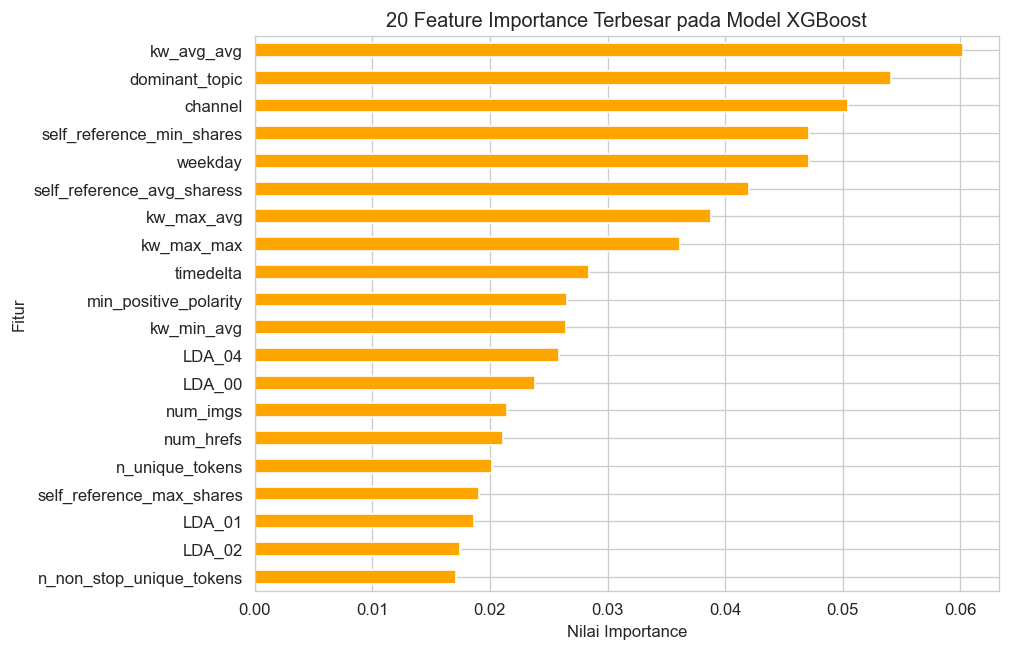

In [32]:
# Mengambil feature importance dari model XGBoost
feature_importance = pd.Series(
    xgb_search.best_estimator_.feature_importances_,
    index=X_train.columns
)

# Ambil 20 fitur terpenting
top_features = feature_importance.nlargest(20).sort_values()

# Membuat plot
plt.figure(figsize=(8,6))

top_features.plot(
    kind='barh',
    color='orange'
)

plt.title('20 Feature Importance Terbesar pada Model XGBoost')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur')

plt.show()

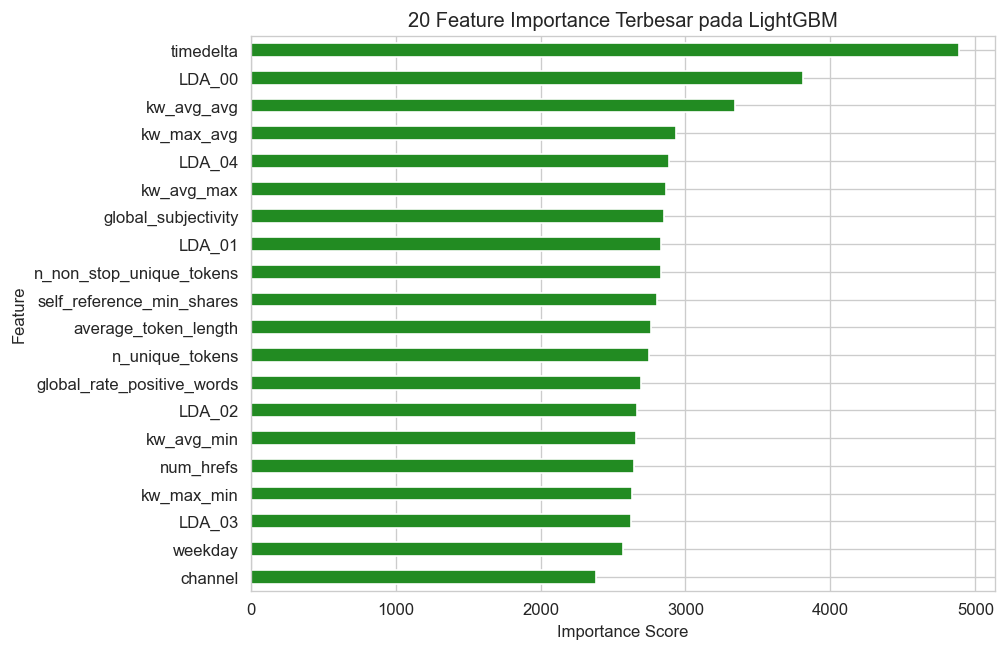

In [37]:
feature_importance = pd.Series(
    lgbm_search.best_estimator_.feature_importances_,
    index=X_train.columns
)

# Top 20
top_features = feature_importance.nlargest(20).sort_values()

# Plot
plt.figure(figsize=(8,6))

top_features.plot(
    kind='barh',
    color='forestgreen'
)

plt.title('20 Feature Importance Terbesar pada LightGBM')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

Angka importance score di Light GBM berarti seberapa banyak suatu fitur itu digunakan sebagai split decision pada sebuah tree di model

### Model Comparism 

In [46]:
comparison_df = pd.DataFrame({
    'Model': [
        'RF Base',
        'RF Tuned',
        'XGB Base',
        'XGB Tuned',
        'LGBM Base',
        'LGBM Tuned'
    ],

    'Accuracy': [
        results['RF_base']['acc'],
        results['RF_tuned']['acc'],
        results['XGB_base']['acc'],
        results['XGB_tuned']['acc'],
        results['lgbm_base']['acc'],
        results['LGBM_tuned']['acc']
    ]
})

print(comparison_df)

        Model  Accuracy
0     RF Base  0.655947
1    RF Tuned  0.656829
2    XGB Base  0.671585
3   XGB Tuned  0.672342
4   LGBM Base  0.665279
5  LGBM Tuned  0.672720


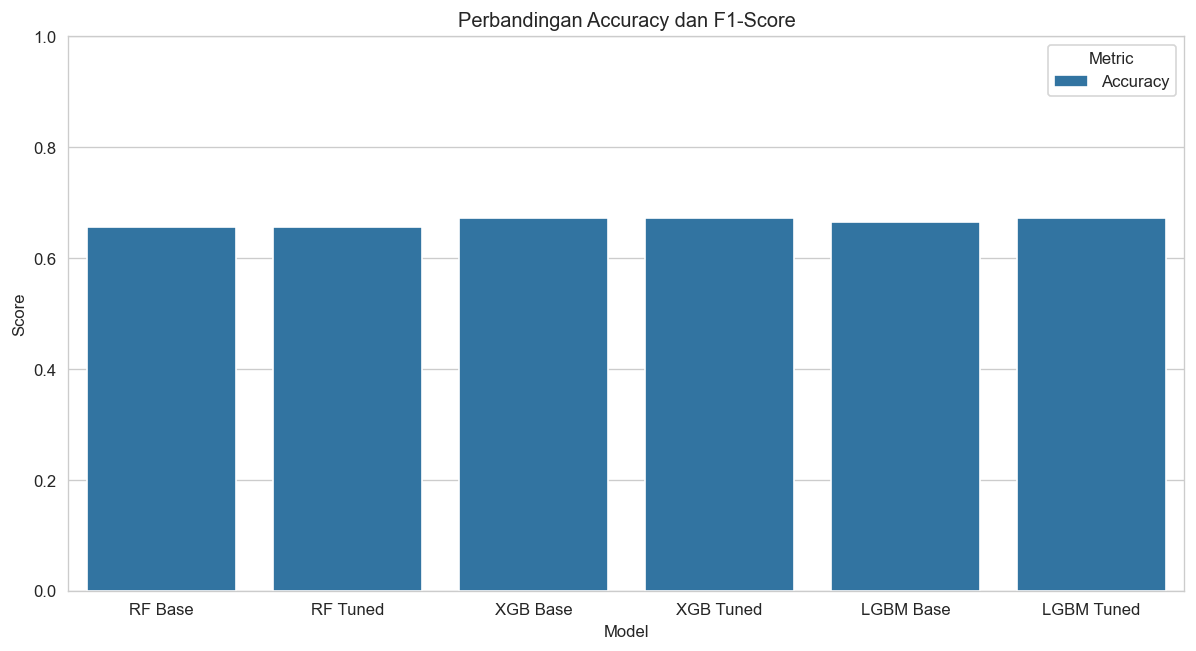

In [49]:
# Ubah format dataframe
comparison_melt = comparison_df.melt(
    id_vars='Model',
    value_vars=['Accuracy'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_melt,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title('Perbandingan Accuracy dan F1-Score')
plt.xlabel('Model')
plt.ylabel('Score')

plt.ylim(0,1)

plt.legend(title='Metric')

plt.show()